In [19]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from dotenv import load_dotenv


In [20]:
load_dotenv()

generator_model = ChatGoogleGenerativeAI(model= "gemini-2.5-flash-lite")
evaluator_model = ChatGoogleGenerativeAI(model= "gemini-2.5-flash")
optimizer_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [21]:
from pydantic import Field
from pydantic import BaseModel
class TweetSchema(BaseModel):
    evaluation: Literal['approved', 'needs_improvement'] = Field(description= "Final evaluation result.")
    feedback: str = Field(description="feedback for the tweet.")

In [22]:
import operator
from typing import Annotated
class StateTweet(TypedDict):
    topic: str
    tweet: str
    feedback: str
    evaluation: Literal['approved', 'needs_improvement']
    iterator: int
    max_iterator: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [23]:
structure_model = evaluator_model.with_structured_output(TweetSchema)

In [31]:
from langchain_core.messages import HumanMessage
from langchain_core.messages import SystemMessage
def genearate_tweet(state: StateTweet):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_model.invoke(messages).content

    return {'tweet': response, 'tweet_history': [response]}

In [32]:
def eval_tweet(state: StateTweet):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
    ]
    response = structure_model.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [33]:
def optimize_tweet(state: StateTweet):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_model.invoke(messages).content
    iteration = state['iterator'] + 1

    return {'tweet': response, 'iterator': iteration, 'tweet_history': [response]}

In [34]:
def route_evaluation(state: StateTweet):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [35]:
graph = StateGraph(StateTweet)

graph.add_node("tweet_gen", genearate_tweet)
graph.add_node("evaluate_tweet", eval_tweet)
graph.add_node("optimise_tweet", optimize_tweet)

graph.add_edge(START, "tweet_gen")
graph.add_edge("tweet_gen", "evaluate_tweet")

graph.add_conditional_edges("evaluate_tweet", route_evaluation, {'approved': END, 'needs_improvement': 'optimise_tweet'})
graph.add_edge("optimise_tweet", "evaluate_tweet")

workflow = graph.compile()

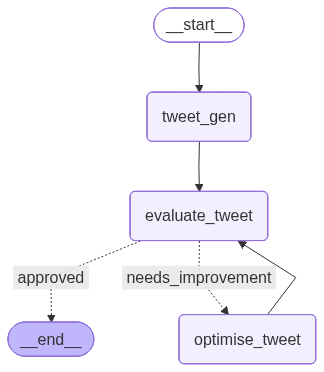

In [36]:
workflow

In [41]:
initial_state = {
    "topic": "Donald Tatya",
    "iterator": 1,
    "max_iterator": 5
}
result = workflow.invoke(initial_state)

In [42]:
result

{'topic': 'Donald Tatya',
 'tweet': "Donald Tatya's hair is like my Wi-Fi signal: sometimes it's there, sometimes it's... a bold statement. 🤷\u200d♀️ #DonaldTatya #HairGoalsOrNoGoals",
 'feedback': "This tweet is approved due to its clever use of a relatable Wi-Fi analogy to humorously comment on hair, offering a relatively fresh take. It is concise, well-formatted, and adheres to character limits, avoiding the pitfalls of traditional setup-punchline jokes or question-answer formats. The humor lands with a subtle chuckle, and the inclusion of relevant hashtags is appropriate. While the specific name 'Donald Tatya' might limit its immediate virality to a niche audience, the underlying comparison is broadly relatable and effective.",
 'evaluation': 'approved',
 'iterator': 1,
 'max_iterator': 5,
 'tweet_history': ["Donald Tatya's hair is like my Wi-Fi signal: sometimes it's there, sometimes it's... a bold statement. 🤷\u200d♀️ #DonaldTatya #HairGoalsOrNoGoals"],
 'feedback_history': ["Thi